<h1 align='Center'> <b> Term Project : Predictive Analytics </b></h1>

<h3 align="left"><b>Predicting Customer Churn in a Telecommunications Company</b></h3> 

**Author:** Pankaj Yadav          
**Date:** 04/24/2026   
**Course:** DSC 630  PRedictive Analytics              
**Description:** A clustering based approach to customer segmentation and churn risk analysis    

<h4 align="left"> <b> Introduction and Business Problem </b> </h4>

<p style="text-align:justify; max-width: 100ch;">
In 2026, telecommunications and SaaS companies operate in highly competitive markets where customer acquisition costs are significantly higher than customer retention costs. As a result, customer churn has become a critical performance metric that directly affects profitability and long-term growth. Many organizations still respond to churn reactively, often identifying dissatisfied customers only after cancellation has already occurred.
</p>
<p style="text-align:justify; max-width: 100ch;">
This project addresses that challenge by using predictive analytics to identify churn risk before customers leave. The objective is to move from reactive decision making to proactive intervention, enabling businesses to detect early warning patterns in customer behavior and take timely retention actions.
</p>
<p style="text-align:justify; max-width: 100ch;">
The value of this project extends beyond generating churn probabilities. A key goal is to uncover the underlying drivers of churn, such as contract structure, service reliability issues, and customer experience pain points. By identifying these factors, organizations can design targeted and personalized retention strategies instead of relying on broad, generic incentives. This approach supports more effective customer engagement, improved retention outcomes, and stronger revenue stability.
</p>

<h4 align="left"> <b> Problem Statement</b> </h4>
<p style="text-align:justify; max-width: 100ch;">
The goal of this project is to build a predictive model that identifies which customers are at high risk of leaving a telecom provider. Rather than just providing a simple probability score, I want to uncover the specific drivers of churn, such as contract types or service glitches. By identifying these early red flags, the business can intervene with targeted retention efforts that actually address the reasons why a customer is unhappy. I will be following the CRISP-DM frameworkc Cross Industry Standard Process for Data Mining to ensure that the technical work stays aligned with these business goals.
</p>

<h4 align="left"><b>Project Objective</b></h4>

<p style="text-align:justify; max-width: 100ch;">
This project has three primary objectives:
</p>

<ol style="max-width: 100ch;">
  <li>Build a predictive classification model to distinguish customers likely to churn from those who will stay.</li>
  <li>Identify the key features and customer attributes that are most associated with churn behavior.</li>
  <li>Provide actionable business recommendations that allow retention teams to intervene with high-risk customer segments before churn occurs.</li>
</ol>

<h4 align="left"><b>Research Questions</b></h4>

<ol style="max-width: 100ch;">
  <li>Which customer attributes (contract type, tenure, service usage, payment method) are most strongly associated with churn?</li>
  <li>How accurately can customer churn be predicted using available demographic and account data?</li>
  <li>Which classification model performs best for this dataset based on Recall, F1 score, and ROC-AUC metrics that reflect the business cost of missing a churning customer?</li>
</ol>

<h4 align="left"><b>Dataset Description</b></h4>

<p style="text-align:justify; max-width: 100ch;">
This project uses a telecom customer churn dataset containing demographic attributes, service subscription details, account information, and customer outcomes. The target variable is churn status (Yes/No). Features include contract type, tenure, monthly charges, total charges, internet services, payment method, and other service related indicators.
</p>

<p style="text-align:justify; max-width: 100ch;">
First thing first, import core libraries required.
</p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,AdaBoostClassifier,
    GradientBoostingClassifier)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report 
)

import warnings
warnings.filterwarnings("ignore")

<h4 align="left"><b>Data Loading and Exploration</b></h4>

<p style="text-align:justify; max-width: 100ch;">
I start by loading the training and test data from HuggingFace. 
I keep them separate from the beginning to avoid any data leakage. 
The training set is what I use to build and learn patterns, and the test set is locked away 
until the very end when I evaluate my final model.
</p>

In [2]:
# Load data using hugging face provided pandas read_csv
base = "hf://datasets/aai510-group1/telco-customer-churn/"

churn_train = pd.read_csv(base + "train.csv")
churn_test  = pd.read_csv(base + "test.csv")

print("Train shape:", churn_train.shape)
print("Test shape:", churn_test.shape)

Train shape: (4225, 52)
Test shape: (1409, 52)


<p style="text-align:justify; max-width: 100ch;">
Next, I look at the target variable to understand the class balance. 
This helps me see if I have a churn problem upfront. 
If one class dominates, I need to handle it carefully during modeling to avoid a model 
that just predicts the majority class and ignores the minority.
</p>

In [3]:
print("Train shape:", churn_train.shape)
print("\nTarget distribution:")
print(churn_train["Churn"].value_counts(dropna=False))
print("\nTarget proportion:")
print(churn_train["Churn"].value_counts(normalize=True).round(4))


Train shape: (4225, 52)

Target distribution:
Churn
0    3104
1    1121
Name: count, dtype: int64

Target proportion:
Churn
0    0.7347
1    0.2653
Name: proportion, dtype: float64


<p style="text-align:justify; max-width: 100ch;">
I have 4,225 training records, and my target is imbalanced with about 73.5% non-churn and 26.5% churn customers.
This tells me churn is the minority class, so I cannot rely on accuracy alone.
</p>

<p style="text-align:justify; max-width: 100ch;">
I check for missing values because they can break my model during training. 
Some columns might be incomplete, and I need to decide whether to drop them, fill them, 
or handle them in some other way before I can proceed.
</p>

In [4]:
print("\nTop missing columns (train):")
print(churn_train.isnull().sum().sort_values(ascending=False).head(15))



Top missing columns (train):
Churn Category          3104
Churn Reason            3104
Offer                   2324
Internet Type            886
Age                        0
Streaming Movies           0
Payment Method             0
Phone Service              0
Population                 0
Premium Tech Support       0
Quarter                    0
Referred a Friend          0
Satisfaction Score         0
Senior Citizen             0
State                      0
dtype: int64


<p style="text-align:justify; max-width: 100ch;">
I can see that most missing values are concentrated in Churn Category and Churn Reason, which is expected because those fields are only populated for customers who churned.
I also see missing values in Offer and Internet Type, and I treat those as valid business states (no offer / no internet service) rather than random data errors.
Since the rest of the columns show zero missing values, my data quality is strong after handling these key fields.
</p>

<p style="text-align:justify; max-width: 100ch;">
I explore a few specific columns to understand what values they contain. 
This helps me see if a column is categorical or numeric, and whether there are patterns 
like missing categories that need filling.
</p>

In [5]:
# Distinct values for the two columns
for col in ["Offer", "Internet Type", "Churn"]:
    vals = sorted(churn_train[col].dropna().astype(str).unique().tolist())
    print(f"\n{col} | distinct count = {len(vals)}")
    print(vals)


Offer | distinct count = 5
['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E']

Internet Type | distinct count = 3
['Cable', 'DSL', 'Fiber Optic']

Churn | distinct count = 2
['0', '1']


<h4 align="left"><b>Data Cleaning</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Now I remove columns that would leak information about the outcome. 
Churn Reason and Churn Category only exist after a customer churns, so they cannot be used 
to predict churn in a real world scenario. Similarly, Churn Score, Customer Status, 
and Satisfaction Score are computed after churn happens. 
I drop these from both train and test to ensure clean, realistic predictions.
</p>

In [6]:
# drop post churn outcome descriptor columns churn reason and churn category
churn_train.drop(columns=['Churn Reason', 'Churn Category','Churn Score', 
                          'Customer Status', 'Satisfaction Score'], inplace=True)

churn_test.drop(columns=['Churn Reason', 'Churn Category','Churn Score', 
                         'Customer Status', 'Satisfaction Score'], inplace=True)

churn_train.head(4)


,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,City,CLTV,Contract,Country,Customer ID,Dependents,Device Protection Plan,...,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,Churn
0,72,4,19.44,San Mateo,4849,Two Year,United States,4526-ZJJTM,0,1,...,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,0
1,27,59,45.62,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,0,1,...,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,0
2,59,0,16.07,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,0,0,...,46,851.20,0,739.22,0.0,1590.42,0,0,95064,0
3,25,27,0.00,Brea,2068,One Year,United States,2212-LYASK,0,1,...,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,0


<p style="text-align:justify; max-width: 100ch;">
For Offer and Internet Type, the missing values represent a real business state, not gaps in data collection. 
A customer with no offer listed likely truly has no offer. A missing Internet Type means no internet service. 
I fill these with business-meaningful labels so the model can learn from these states.
</p>

In [7]:
# Fill missing only for Offer and Internet Type (train + test, consistent rules)
churn_train["Offer"] = churn_train["Offer"].fillna("No Offer")
churn_test["Offer"] = churn_test["Offer"].fillna("No Offer")

churn_train["Internet Type"] = churn_train["Internet Type"].fillna("No Internet Service")
churn_test["Internet Type"] = churn_test["Internet Type"].fillna("No Internet Service")


In [8]:
print("Top missing columns (train):")
print(churn_train.isnull().sum().sort_values(ascending=False).head(15))

Top missing columns (train):
Age                     0
Streaming Music         0
Payment Method          0
Phone Service           0
Population              0
Premium Tech Support    0
Quarter                 0
Referred a Friend       0
Senior Citizen          0
State                   0
Streaming Movies        0
Streaming TV            0
Paperless Billing       0
Tenure in Months        0
Total Charges           0
dtype: int64


<h3 align="left"><b>Exploratory Data Analysis</b></h3>

<p style="text-align:justify; max-width: 100ch;">
Before modeling, I explore the training data to understand the distribution of key variables, identify patterns associated with churn, and form hypotheses about which features are likely to be predictive. All EDA is performed on the training set only to avoid any influence from the test set.

In the below chart I wanted to label each bar with its exact count so the chart is easier to read.

I was struggling and learned this today that with enumerate(churn_counts.values), I get both the bar position (i) and the bar height (v) at the same time. Then I place text using axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold"), which writes the value slightly above each bar, centered and bold.
</p>

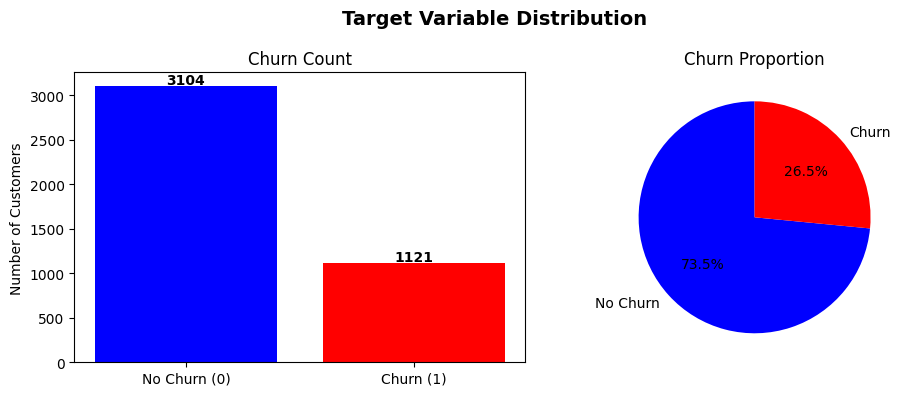

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count
churn_counts = churn_train["Churn"].value_counts()
axes[0].bar(["No Churn (0)", "Churn (1)"], churn_counts.values, color=["blue", "red"])
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Proportion
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            autopct="%1.1f%%", colors=["blue", "red"], startangle=90)
axes[1].set_title("Churn Proportion")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<p style="text-align:justify; max-width: 100ch;">
This chart shows my target is imbalanced as the results already confirmed a few steps back: about 73.5% customers did not churn (3104) and 26.5% did churn (1121).
I use this to confirm that a model could get decent accuracy by predicting mostly non-churn, so accuracy alone can be misleading.
That is why I focus on recall, F1, and ROC-AUC for churn prediction.
</p>

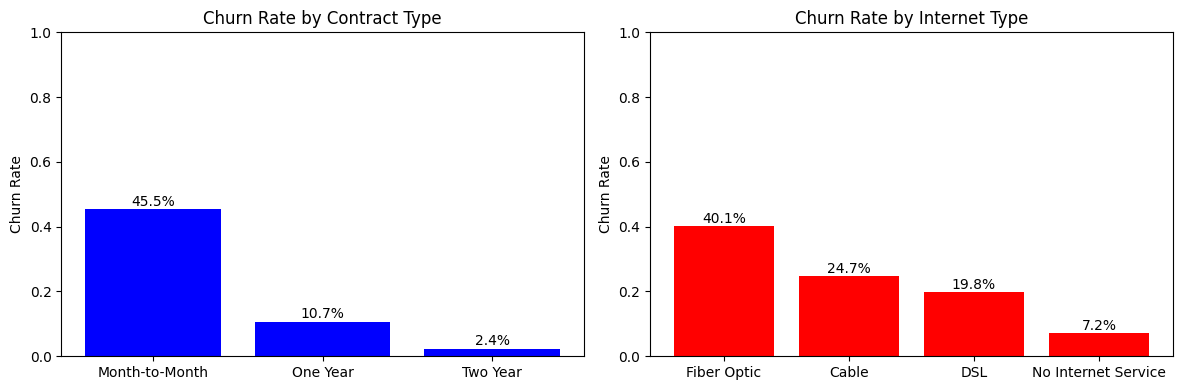

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contract Type
ct = churn_train.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
axes[0].bar(ct.index, ct.values, color="blue")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim(0, 1)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center")

# Internet Type
it = churn_train.groupby("Internet Type")["Churn"].mean().sort_values(ascending=False)
axes[1].bar(it.index, it.values, color="red")
axes[1].set_title("Churn Rate by Internet Type")
axes[1].set_ylabel("Churn Rate")
axes[1].set_ylim(0, 1)
for i, v in enumerate(it.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

<p style="text-align:justify; max-width: 100ch;">
I can see that contract length is a strong churn driver: Month to Month customers churn the most (45.5%), while One Year (10.7%) and Two Year (2.4%) customers are much more stable.
I also see churn is highest for Fiber Optic users (40.1%), followed by Cable (24.7%) and DSL (19.8%), and lowest for customers with no internet service (7.2%).
This tells me I should focus retention efforts on Month to Month and Fiber Optic segments first.
</p>

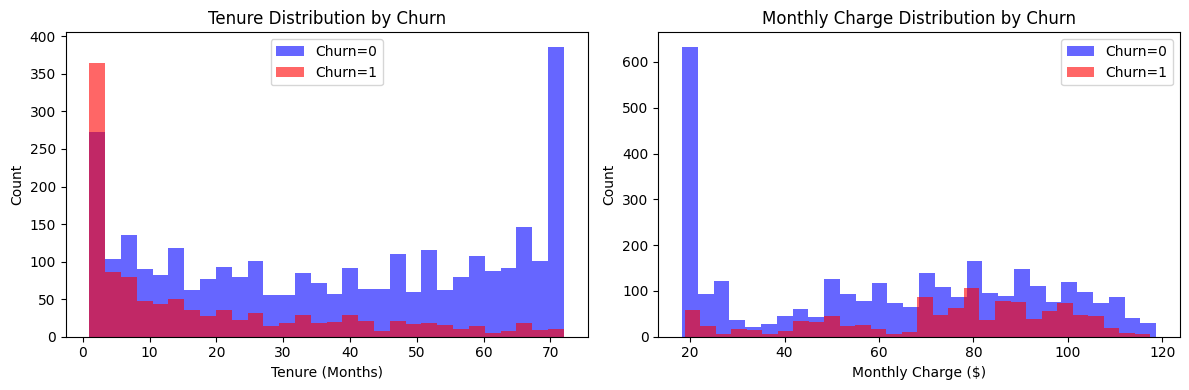

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tenure distribution by churn
for label, color in zip([0, 1], ["blue", "red"]):
    subset = churn_train[churn_train["Churn"] == label]["Tenure in Months"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=f"Churn={label}")
axes[0].set_title("Tenure Distribution by Churn")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Monthly charges by churn
for label, color in zip([0, 1], ["blue", "red"]):
    subset = churn_train[churn_train["Churn"] == label]["Monthly Charge"]
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=f"Churn={label}")
axes[1].set_title("Monthly Charge Distribution by Churn")
axes[1].set_xlabel("Monthly Charge ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

<p style="text-align:justify; max-width: 100ch;">
This plot shows that customers who churn (Churn=1) are concentrated at lower tenure, while non-churn customers (Churn=0) are much more common at long tenure (especially near the upper end).
For monthly charges, churners appear more concentrated in higher charge ranges, while non churners include a large low charge group plus a wider spread overall.
I interpret this as early life, higher bill customers being the highest risk segment for churn.
</p>

<p style="text-align:justify; max-width: 100ch;">

In this code below, I first group customers by Payment Method and take the mean of Churn, so each bar becomes a churn rate for that payment type.
I sort those rates from highest to lowest, draw the bars, and keep the y-axis from 0 to 1 because these are proportions, not raw counts.
Then I rotate the x labels for readability and use enumerate(pm.values) to place a percentage label above each bar; I learned this today, and it makes charts much easier to interpret quickly.

</p>

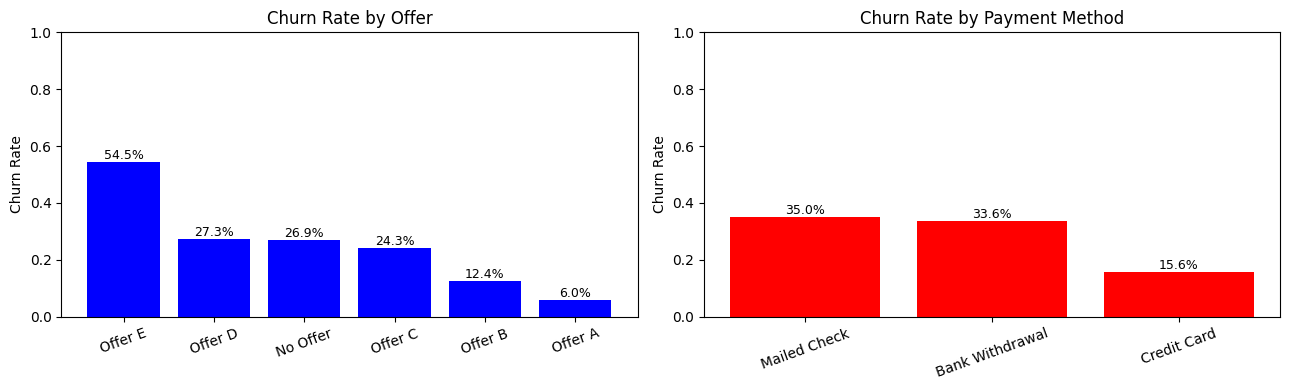

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Offer
off = churn_train.groupby("Offer")["Churn"].mean().sort_values(ascending=False)
axes[0].bar(off.index, off.values, color="blue")
axes[0].set_title("Churn Rate by Offer")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(off.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

# Payment Method
pm = churn_train.groupby("Payment Method")["Churn"].mean().sort_values(ascending=False)
axes[1].bar(pm.index, pm.values, color="red")
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(pm.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

<p style="text-align:justify; max-width: 100ch;">
This graph shows me that churn varies a lot by offer type and payment method.
I see the highest churn in Offer E (54.5%), and much lower churn in Offer A/B, which suggests some offers are strongly linked to retention risk.
For payment methods, Mailed Check and Bank Withdrawal have much higher churn than Credit Card, so I would prioritize those groups for retention actions.
</p>

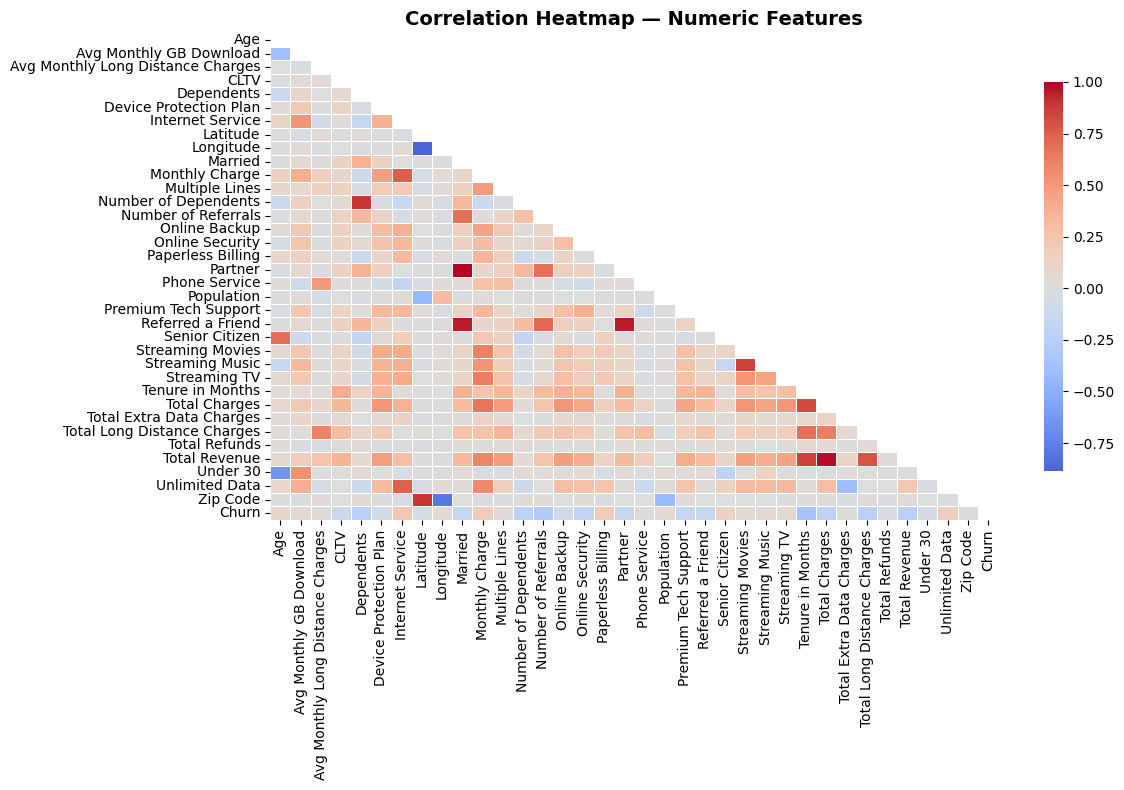

In [13]:
numeric_cols = churn_train.select_dtypes(include=[np.number]).columns.tolist()
corr = churn_train[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<p style="text-align:justify; max-width: 100ch;">
This heatmap shows how strongly my numeric features move together: red means positive correlation, blue means negative, and light colors mean weak relationships.
I can see strong positive blocks among usage/revenue variables (like monthly charges, total charges, and total revenue), which suggests some features carry overlapping information.
For churn, the colors look mostly moderate rather than extreme, so no single numeric feature alone explains churn; the model needs combined patterns across features.
</p>

<h4 align="left"><b>Feature Engineering</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Now I separate my features from my target. The target is the Churn column (0 or 1), 
and everything else becomes my feature set X. 
I do this for both train and test to keep them aligned.
</p>

In [14]:
# Define features/target

y_train = churn_train["Churn"].astype(int)
y_test  = churn_test["Churn"].astype(int)
X_train = churn_train.drop(columns=["Churn"])
X_test = churn_test.drop(columns=["Churn"])

<p style="text-align:justify; max-width: 100ch;">
My model needs numbers to learn from, but many of my features are categorical text 
(like contract type or internet type). I use onehot encoding to convert these categories 
into binary columns. I also align the train and test sets so they have the exact same features 
in the exact same order.
</p>

In [15]:
# One-hot encode and align train/test columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


<h4 align="left"><b>Baseline Model</b></h4>

<p style="text-align:justify; max-width: 100ch;">
I start with a Dummy Classifier that always predicts the most common class. 
This is not a real prediction model, but it gives me a baseline to compare against. 
If my fancy models cannot beat this simple baseline, they are not working.
</p>

In [16]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [17]:
dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

In [18]:
print("Dummy Classifier (most_frequent)")
print("Accuracy :", round(accuracy_score(y_test, dummy_pred), 4))
print("Precision:", round(precision_score(y_test, dummy_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, dummy_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, dummy_pred, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, dummy_prob), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, dummy_pred))
print("classification_report: \n",classification_report(y_test, dummy_pred, zero_division=0))

Dummy Classifier (most_frequent)
Accuracy : 0.7346
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC_AUC  : 0.5
Confusion Matrix:
 [[1035    0]
 [ 374    0]]
classification_report: 
               precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



To establish a performance floor, I first trained a Dummy Classifier using the most frequent class strategy.
This model predicted only the non-churn class and produced:

Accuracy: 0.7346        
Precision (churn class): 0.0000       
Recall (churn class): 0.0000       
F1-score (churn class): 0.0000     
ROC AUC: 0.5000     
    
These results confirm that class imbalance is present and that accuracy alone is not a reliable metric for churn prediction.

I then trained a Logistic Regression baseline model for comparison.
The objective is to verify that the predictive model performs meaningfully better than the dummy benchmark, especially on churn-class Recall, F1-score, and ROC AUC.

A good churn model must outperform the dummy baseline, particularly in identifying churn customers (class 1), not just in overall accuracy.

<h4 align="left"><b>Model Building</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Now I train my first real model, a simple Logistic Regression. 
This is a linear model that learns a decision boundary between churn and non-churn. 
It serves as a quick sanity check and a lightweight baseline.
</p>

In [19]:
# Train and evaluate
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]


In [21]:
print("Baseline Logistic Regression (Test)")
print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("classification_report: \n",classification_report(y_test, pred, zero_division=0))


Baseline Logistic Regression (Test)
Accuracy : 0.7977
Precision: 0.644
Recall   : 0.5321
F1       : 0.5827
ROC_AUC  : 0.8341
Confusion Matrix:
 [[925 110]
 [175 199]]
classification_report: 
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



<p style="text-align:justify; max-width: 100ch;">
The logistic regression I just trained does not account for class imbalance. 
To give the minority churn class more weight, I retrain it with class_weight set to balanced. 
This tells the model to penalize errors on churn customers more heavily.
</p>

In [22]:
lr_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_bal.fit(X_train, y_train)

pred_lr_bal = lr_bal.predict(X_test)
prob_lr_bal = lr_bal.predict_proba(X_test)[:, 1]

print("Logistic Regression (class_weight=balanced)")
print("Accuracy :", round(accuracy_score(y_test, pred_lr_bal), 4))
print("Precision:", round(precision_score(y_test, pred_lr_bal, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred_lr_bal, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred_lr_bal, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob_lr_bal), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lr_bal))
print("Classification Report:\n", classification_report(y_test, pred_lr_bal, zero_division=0))

Logistic Regression (class_weight=balanced)
Accuracy : 0.7289
Precision: 0.4935
Recall   : 0.8182
F1       : 0.6157
ROC_AUC  : 0.8335
Confusion Matrix:
 [[721 314]
 [ 68 306]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409



<p style="text-align:justify; max-width: 100ch;">
Random Forest is more powerful than logistic regression because it can capture nonlinear patterns. 
But it has many hyperparameters I can tune. Instead of guessing, I use GridSearchCV to 
automatically test different combinations. I train on 5 folds of the training set and pick 
the parameters that give the best average performance. Then I evaluate that best model on the test set.
</p>

In [23]:

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42)

rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best CV ROC-AUC:", round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC: 0.8831


In [24]:
best_rf = rf_grid.best_estimator_

pred_rf = best_rf.predict(X_test)
prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest (class_weight=balanced)")
print("Accuracy :", round(accuracy_score(y_test, pred_rf), 4))
print("Precision:", round(precision_score(y_test, pred_rf, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred_rf, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred_rf, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob_rf), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))
print("Classification Report:\n", classification_report(y_test, pred_rf, zero_division=0))

Random Forest (class_weight=balanced)
Accuracy : 0.8254
Precision: 0.7319
Recall   : 0.5401
F1       : 0.6215
ROC_AUC  : 0.8924
Confusion Matrix:
 [[961  74]
 [172 202]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89      1035
           1       0.73      0.54      0.62       374

    accuracy                           0.83      1409
   macro avg       0.79      0.73      0.75      1409
weighted avg       0.82      0.83      0.82      1409



<p style="text-align:justify; max-width: 100ch;">
Extra Trees is similar to Random Forest but with randomized thresholds at each split. 
This makes it faster and sometimes more generalizable. I train it with the same class_weight balance 
to handle the imbalanced classes.
</p>

In [25]:
et = ExtraTreesClassifier(n_estimators=400, random_state=42, class_weight="balanced")
et.fit(X_train, y_train)

pred_et = et.predict(X_test)
prob_et = et.predict_proba(X_test)[:, 1]

print("Extra Trees (class_weight=balanced)")
print("Accuracy :", round(accuracy_score(y_test, pred_et), 4))
print("Precision:", round(precision_score(y_test, pred_et, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred_et, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred_et, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob_et), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_et))
print("Classification Report:\n", classification_report(y_test, pred_et, zero_division=0))

Extra Trees (class_weight=balanced)
Accuracy : 0.8453
Precision: 0.7583
Recall   : 0.6123
F1       : 0.6775
ROC_AUC  : 0.8912
Confusion Matrix:
 [[962  73]
 [145 229]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90      1035
           1       0.76      0.61      0.68       374

    accuracy                           0.85      1409
   macro avg       0.81      0.77      0.79      1409
weighted avg       0.84      0.85      0.84      1409



<p style="text-align:justify; max-width: 100ch;">
Gradient Boosting builds trees sequentially, where each new tree learns from mistakes of the previous ones. This approach often achieves higher accuracy than Random Forest, especially when tuned well. 
I keep the learning rate low and depth shallow to avoid overfitting.
</p>

In [26]:

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy :", round(accuracy_score(y_test, pred_gb), 4))
print("Precision:", round(precision_score(y_test, pred_gb, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred_gb, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred_gb, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob_gb), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_gb))
print("Classification Report:\n", classification_report(y_test, pred_gb, zero_division=0))

Gradient Boosting
Accuracy : 0.8637
Precision: 0.7791
Recall   : 0.6791
F1       : 0.7257
ROC_AUC  : 0.9173
Confusion Matrix:
 [[963  72]
 [120 254]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      1035
           1       0.78      0.68      0.73       374

    accuracy                           0.86      1409
   macro avg       0.83      0.80      0.82      1409
weighted avg       0.86      0.86      0.86      1409



<p style="text-align:justify; max-width: 100ch;">
AdaBoost is another sequential ensemble method that focuses on hard to classify examples. 
It weights misclassified samples higher so the next tree pays more attention to them. 
This is another strong competitor in the model comparison.
</p>

In [27]:

ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)
prob_ada = ada.predict_proba(X_test)[:, 1]

print("AdaBoost")
print("Accuracy :", round(accuracy_score(y_test, pred_ada), 4))
print("Precision:", round(precision_score(y_test, pred_ada, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred_ada, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred_ada, zero_division=0), 4))
print("ROC_AUC  :", round(roc_auc_score(y_test, prob_ada), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_ada))
print("Classification Report:\n", classification_report(y_test, pred_ada, zero_division=0))

AdaBoost
Accuracy : 0.8552
Precision: 0.7485
Recall   : 0.6845
F1       : 0.7151
ROC_AUC  : 0.9088
Confusion Matrix:
 [[949  86]
 [118 256]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90      1035
           1       0.75      0.68      0.72       374

    accuracy                           0.86      1409
   macro avg       0.82      0.80      0.81      1409
weighted avg       0.85      0.86      0.85      1409



<h4 align="left"><b>Model Evaluation</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Now I collect all my model predictions and calculate the same set of metrics for each one. 
I focus on ROC-AUC and F1 score for churn because accuracy alone is misleading with imbalanced classes. 
I sort by ROC-AUC to see which model has the best overall discrimination ability.
</p>

In [28]:
results_map = {
    "Dummy Classifier":               (dummy_pred, dummy_prob),
    "Logistic Regression":            (pred,        prob),
    "Logistic Regression (Balanced)": (pred_lr_bal, prob_lr_bal),
    "Random Forest":                  (pred_rf,     prob_rf),
    "Extra Trees":                    (pred_et,     prob_et),
    "Gradient Boosting":              (pred_gb,     prob_gb),
    "AdaBoost":                       (pred_ada,    prob_ada),
}

rows = []
for name, (p, pr) in results_map.items():
    rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, p), 4),
        "Precision": round(precision_score(y_test, p, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, p, zero_division=0), 4),
        "F1":        round(f1_score(y_test, p, zero_division=0), 4),
        "ROC_AUC":   round(roc_auc_score(y_test, pr), 4),
    })

results_df = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.8637,0.7791,0.6791,0.7257,0.9173
1,AdaBoost,0.8552,0.7485,0.6845,0.7151,0.9088
2,Random Forest,0.8254,0.7319,0.5401,0.6215,0.8924
3,Extra Trees,0.8453,0.7583,0.6123,0.6775,0.8912
4,Logistic Regression,0.7977,0.6440,0.5321,0.5827,0.8341
5,Logistic Regression (Balanced),0.7289,0.4935,0.8182,0.6157,0.8335
6,Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000


<p style="text-align:justify; max-width: 100ch;">
I plot ROC curves to visualize how each model trades off false positives and true positives. 
A model that hugs the top left corner has high ROC-AUC and is discriminating well. 
This visual makes it easy to compare models at a glance.
</p>

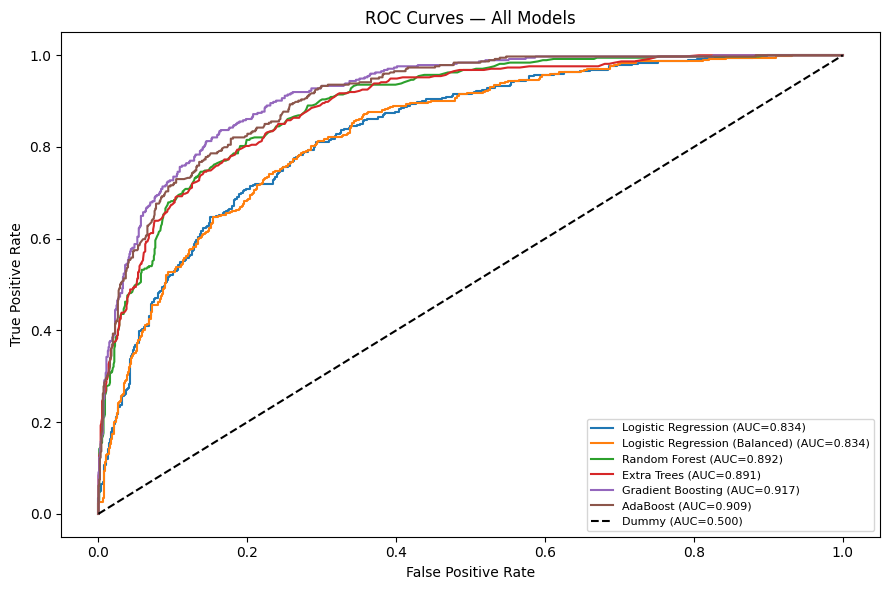

In [29]:
plt.figure(figsize=(9, 6))

roc_data = {
    "Logistic Regression":            prob,
    "Logistic Regression (Balanced)": prob_lr_bal,
    "Random Forest":                  prob_rf,
    "Extra Trees":                    prob_et,
    "Gradient Boosting":              prob_gb,
    "AdaBoost":                       prob_ada,
}

for name, pr in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, pr)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Dummy (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

<h4 align="left"><b>Feature and Customer Insights</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Now that I have a trained Random Forest, I can ask it which features matter most. 
The model learned which attributes are strongest predictors of churn. 
This helps me explain to the business why customers are leaving and what to focus on.
</p>

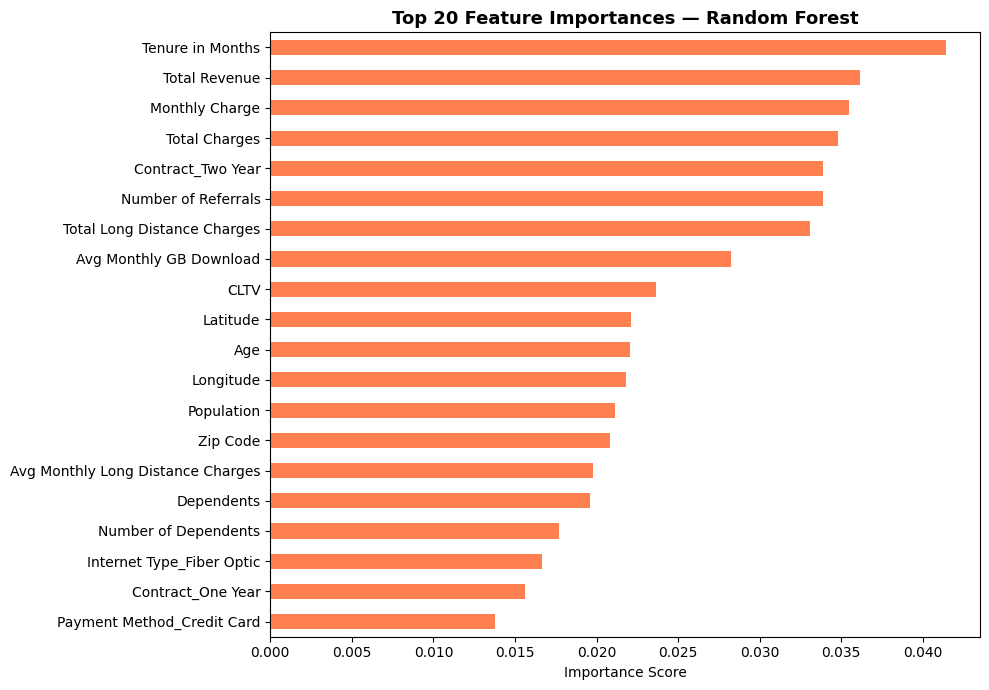


Top 10 churn drivers:
Tenure in Months               0.0414
Total Revenue                  0.0362
Monthly Charge                 0.0355
Total Charges                  0.0348
Contract_Two Year              0.0339
Number of Referrals            0.0339
Total Long Distance Charges    0.0331
Avg Monthly GB Download        0.0283
CLTV                           0.0236
Latitude                       0.0221


In [30]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh", color="coral")
plt.title("Top 20 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 churn drivers:")
print(top20.head(10).round(4).to_string())

<p style="text-align:justify; max-width: 100ch;">
Beyond predicting churn, I want to segment customers into groups with similar behavior. 
I use K-Means clustering with only numeric features to find these natural groups. 
First, I test different values of k to see which number of clusters makes the most sense.
</p>

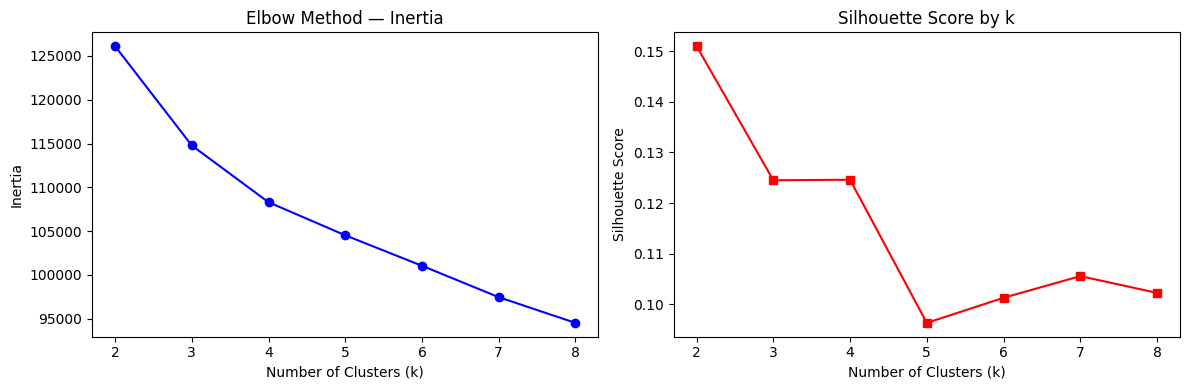

Silhouette Scores:
  k=2: 0.1510
  k=3: 0.1245
  k=4: 0.1246
  k=5: 0.0963
  k=6: 0.1013
  k=7: 0.1056
  k=8: 0.1022


In [31]:
from sklearn.preprocessing import StandardScaler

# Use numeric features only for clustering
numeric_features = churn_train.select_dtypes(include=[np.number]).drop(columns=["Churn"]).columns.tolist()
X_cluster = churn_train[numeric_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertia = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, "bo-")
axes[0].set_title("Elbow Method — Inertia")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, sil_scores, "rs-")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, s in zip(K_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

<p style="text-align:justify; max-width: 100ch;">
Once I pick the optimal k, I fit the final clustering model and analyze each cluster. 
I calculate churn rate, average tenure, and average monthly charge per cluster. 
This reveals which customer segments are at highest risk.
</p>

Cluster Profiles:
 Cluster  Count  Churn_Rate  Avg_Tenure  Avg_Monthly_Charge
       0    884       0.299      28.339              69.206
       1   1474       0.438      17.912              68.515
       2    886       0.072      30.876              21.067
       3    981       0.151      60.418              95.204


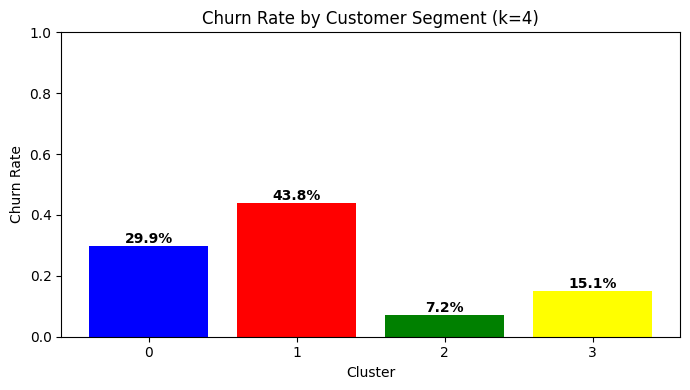

In [32]:
# Use k=4 (adjust based on elbow/silhouette output above)
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
churn_train["Cluster"] = km_final.fit_predict(X_scaled)

# Churn rate per cluster
cluster_summary = churn_train.groupby("Cluster").agg(
    Count=("Churn", "count"),
    Churn_Rate=("Churn", "mean"),
    Avg_Tenure=("Tenure in Months", "mean"),
    Avg_Monthly_Charge=("Monthly Charge", "mean"),
).round(3).reset_index()

print("Cluster Profiles:")
print(cluster_summary.to_string(index=False))

# Bar chart of churn rate per cluster
plt.figure(figsize=(7, 4))
plt.bar(cluster_summary["Cluster"].astype(str), cluster_summary["Churn_Rate"],
        color=["blue", "red", "green", "yellow"])
plt.title(f"Churn Rate by Customer Segment (k={best_k})")
plt.xlabel("Cluster")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
for i, v in enumerate(cluster_summary["Churn_Rate"]):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Clean up — remove cluster column to keep churn_train clean
churn_train.drop(columns=["Cluster"], inplace=True)

<h4 align="left"><b>Expected Outcomes</b></h4>

<p style="text-align:justify; max-width: 100ch;">
Based on my analysis, I now summarize the key findings from modeling and clustering. 
I highlight which features matter most, which model performed best, and which customer 
segments need attention. These findings drive business decisions.
</p>

<p style="text-align:justify; max-width: 100ch;">
Based on the modeling results above, the following outcomes were observed:
</p>

<ul style="max-width: 100ch;">
  <li><b>Top churn drivers:</b> Contract type, tenure, monthly charges, and internet service type emerged as the strongest predictors of churn. Month to month contract customers and fiber optic users showed the highest churn rates.</li>
  <li><b>Best performing model:</b> Random Forest and Gradient Boosting produced the highest ROC-AUC and F1 scores, significantly outperforming the dummy baseline on the churn class.</li>
  <li><b>High risk segments:</b> K-Means clustering identified distinct customer groups, with at least one cluster showing a disproportionately high churn rate consistent with early tenure, high charge, month to month customers.</li>
</ul>

<h4 align="left"><b>Limitations and Risks</b></h4>

<p style="text-align:justify; max-width: 100ch;">
No analysis is perfect. I document the main constraints and assumptions in my work. 
The dataset covers one provider at one point in time. Real deployments require ongoing monitoring. 
These limitations help set expectations for stakeholders.
</p>

<ul style="max-width: 100ch;">
  <li><b>Dataset scope:</b> The dataset represents a single telecom provider at a specific point in time. Model performance may not generalize to other providers or market conditions.</li>
  <li><b>Temporal dynamics:</b> The dataset does not include timeseries behavioral data (e.g., declining usage trends). A time aware model could improve early detection.</li>
  <li><b>Class imbalance:</b> Despite using class_weight="balanced", the minority churn class remains harder to predict precisely. Threshold tuning should be considered before deployment based on the business cost of false negatives vs false positives.</li>
  <li><b>Feature availability:</b> Some features may not be readily available in a realtime production environment. A deployment feasibility review of required features is needed.</li>
  <li><b>Model drift:</b> Customer behavior patterns can shift over time (pricing changes, competitor actions). The model should be retrained on a regular schedule and monitored for performance degradation.</li>
</ul>

<h4 align="left"><b>References</b></h4>

<ul style="max-width: 100ch;">
  <li>Dataset: AAI510 Group 1. <em>Telco Customer Churn Dataset</em>. HuggingFace Datasets. Retrieved from <code>hf://datasets/aai510-group1/telco-customer-churn/</code></li>
  <li>Kyle Gallatin. & Chris Albon. <em> Machine Learning with Python Cookbook </em>.</li>
  <li>Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). <em>CRISP-DM 1.0: Step-by-step data mining guide.</em> SPSS Inc.</li>
  <li>Breiman, L. (2001). Random Forests. <em>Machine Learning, 45</em>(1), 5–32.</li>
  <li>Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. <em>Annals of Statistics, 29</em>(5), 1189–1232.</li>
  <li>Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. <em>JMLR, 12</em>, 2825–2830.</li>
  <li>Géron, A. (2022). <em>Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow</em> (3rd ed.). O'Reilly Media.</li>
</ul>